# **05 LangGraph - Tools와 Agent 챗봇**

### 학습 내용
1. Tool 정의와 사용법
2. Tool을 활용하는 Agent 구현
3. Tool 호출과 응답 처리
4. 조건부 로직으로 Tool 실행 제어
5. 실용적인 Agent 챗봇 구축

## 1. 환경 설정

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("API Key가 설정되었습니다.")

API Key가 설정되었습니다.


## 2. Tool이란?

**Tool**은 LLM이 외부 기능을 사용할 수 있게 해주는 함수입니다.

### Tool의 특징

| 특징 | 설명 |
|-----|------|
| 함수 기반 | Python 함수를 Tool로 변환 |
| 타입 힌트 | 파라미터와 반환 타입 명시 |
| Docstring | Tool의 설명과 파라미터 정보 |
| LLM 호출 | LLM이 필요에 따라 자동 호출 |

### Tool 사용 시나리오

- **계산**: 수학 연산, 통계 계산
- **검색**: 웹 검색, 데이터베이스 조회
- **데이터 처리**: 데이터 변환, 분석
- **API 호출**: 외부 API 연동
- **파일 작업**: 파일 읽기/쓰기

## 3. 간단한 Tool 정의하기

`@tool` 데코레이터를 사용하여 함수를 Tool로 만듭니다.

In [2]:
from langchain.tools import tool

# Tool 정의
@tool
def multiply(a: int, b: int) -> int:
    """두 숫자를 곱합니다.

    Args:
        a: 첫 번째 숫자
        b: 두 번째 숫자
    Returns:
        두 숫자의 곱
    """
    return a * b

@tool
def add(a: int, b: int) -> int:
    """두 숫자를 더합니다.

    Args:
        a: 첫 번째 숫자
        b: 두 번째 숫자
    Returns:
        두 숫자의 합
    """
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """a를 b로 나눕니다.

    Args:
        a: 분자
        b: 분모
    Returns:
        a를 b로 나눈 결과
    """
    return a / b

### 3-1. Tool 직접 호출하기

Tool은 일반 함수처럼 직접 호출할 수 있습니다.

In [3]:
# Tool 직접 호출
result1 = multiply.invoke({"a": 3, "b": 5})
result2 = add.invoke({"a": 10, "b": 20})
result3 = divide.invoke({"a": 100, "b": 4})

print(f"3 × 5 = {result1}")
print(f"10 + 20 = {result2}")
print(f"100 ÷ 4 = {result3}")

3 × 5 = 15
10 + 20 = 30
100 ÷ 4 = 25.0


## 4. LLM에 Tool 바인딩하기

`bind_tools()`를 사용하여 LLM이 Tool을 사용할 수 있게 합니다.

In [4]:
from langchain.chat_models import init_chat_model

# LLM 초기화
llm = init_chat_model("gpt-4o-mini")

# Tool 리스트
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}

# LLM에 Tool 바인딩
llm_with_tools = llm.bind_tools(tools)

print(f"사용 가능한 Tools: {list(tools_by_name.keys())}")

사용 가능한 Tools: ['add', 'multiply', 'divide']


### 4-1. LLM의 Tool 호출 확인

LLM이 Tool을 호출할지 결정합니다.

In [5]:
from langchain.messages import HumanMessage

# 계산을 요청하는 메시지
messages = [HumanMessage(content="3과 4를 더해주세요.")]
response = llm_with_tools.invoke(messages)

print("응답 내용:", response.content)
print("\nTool 호출 정보:")
print(response.tool_calls)

응답 내용: 

Tool 호출 정보:
[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_UWeRfN8qmhp4xSA0MVr3iDBC', 'type': 'tool_call'}]


In [8]:
messages = [HumanMessage(content="안녕")]
response = llm_with_tools.invoke(messages)
print(response)
print(response.content)
print(response.tool_calls)

content='안녕하세요! 어떻게 도와드릴까요?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 173, 'total_tokens': 184, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_53fe5a8400', 'id': 'chatcmpl-DPjJOE7KckZDnChNj9oC4oKO9D5iT', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019d47b8-3a6f-7611-8481-b67ed2b62ff2-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 173, 'output_tokens': 11, 'total_tokens': 184, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
안녕하세요! 어떻게 도와드릴까요?
[]


## 5. State 정의하기

Agent의 상태를 정의합니다. 메시지와 LLM 호출 횟수를 추적합니다.

In [9]:
from typing_extensions import TypedDict, Annotated
from langchain.messages import AnyMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    llm_calls: int

## 6. Agent 노드 정의하기

### 6-1. LLM 호출 노드

LLM을 호출하여 Tool 사용 여부를 결정합니다.

In [10]:
from langchain.messages import SystemMessage

def llm_node(state: AgentState):
    """LLM을 호출하여 응답하거나 Tool 호출을 결정합니다."""

    system_message = SystemMessage(
        content="당신은 수학 계산을 도와주는 AI 어시스턴트입니다. 필요하면 도구를 사용하세요."
    )

    response = llm_with_tools.invoke(
        [system_message] + state["messages"]
    )

    return {
        "messages": [response], # 도구 호출이 발생했다면, tool_calls에 호출된 도구 정보가 포함됩니다. / 도구 호출이 필요없다면, 바로 AIMessage 형태의 응답이 반환됩니다.
        "llm_calls": state.get("llm_calls", 0) + 1
    }

### 6-2. Tool 실행 노드

LLM이 요청한 Tool을 실행하고 결과를 반환합니다.

In [11]:
from langchain.messages import ToolMessage

def tool_node(state: AgentState):
    """LLM이 요청한 Tool을 실행합니다."""

    outputs = []

    # 마지막 메시지의 tool_calls 처리
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        result = tool.invoke(tool_call["args"])

        # ToolMessage 생성
        outputs.append(
            ToolMessage(
                content=str(result),
                tool_call_id=tool_call["id"]
            )
        )

    return {"messages": outputs}

## 7. 조건부 종료 로직

LLM이 Tool을 호출했는지에 따라 다음 동작을 결정합니다.

In [12]:
from typing import Literal
from langgraph.graph import END

def should_continue(state: AgentState) -> Literal["tool_node", "__end__"]:
    """Tool 호출이 있으면 tool_node로, 없으면 종료합니다."""

    last_message = state["messages"][-1]

    # Tool 호출이 있으면 tool_node로
    if last_message.tool_calls:
        return "tool_node"

    # 없으면 종료
    return "__end__" # LLM으로 부터 이미 AI Message 응답이 온 경우

## 8. Agent 그래프 구성하기

모든 구성 요소를 연결하여 Agent를 만듭니다.

In [13]:
from langgraph.graph import StateGraph, START, END

# 그래프 빌더 생성
agent_builder = StateGraph(AgentState)

# 노드 추가
agent_builder.add_node("llm_node", llm_node)
agent_builder.add_node("tool_node", tool_node)

# 엣지 연결
agent_builder.add_edge(START, "llm_node")
agent_builder.add_conditional_edges(
    "llm_node",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_node")  # 반복

# 컴파일
agent = agent_builder.compile()

### 8-1. Agent 그래프 시각화

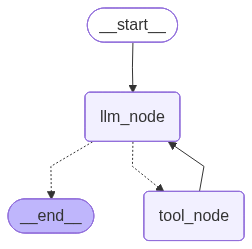

In [14]:
from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

## 9. Agent 실행하기

### 9-1. 단순 계산 요청

In [15]:
# 간단한 덧셈
messages = [HumanMessage(content="3과 4를 더해주세요.")]
result = agent.invoke({"messages": messages, "llm_calls": 0})

print("="*60)
print("실행 결과:")
for msg in result["messages"]:
    msg.pretty_print()
print(f"\n총 LLM 호출 횟수: {result['llm_calls']}")

실행 결과:
================================ Human Message =================================

3과 4를 더해주세요.
================================== Ai Message ==================================
Tool Calls:
  add (call_hvBFnE6AvXKhb0zX6XKLtVmU)
 Call ID: call_hvBFnE6AvXKhb0zX6XKLtVmU
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

3과 4를 더한 결과는 7입니다.

총 LLM 호출 횟수: 2


### 9-2. 복잡한 계산 요청

In [16]:
# 여러 연산을 포함하는 요청
messages = [HumanMessage(content="10과 5를 곱한 다음, 그 결과에 20을 더해주세요.")]
result = agent.invoke({"messages": messages, "llm_calls": 0})

print("="*60)
print("실행 결과:")
for msg in result["messages"]:
    msg.pretty_print()
print(f"\n총 LLM 호출 횟수: {result['llm_calls']}")

실행 결과:
================================ Human Message =================================

10과 5를 곱한 다음, 그 결과에 20을 더해주세요.
================================== Ai Message ==================================
Tool Calls:
  multiply (call_ZJi2pCPlwFAH3atMshKxiT5p)
 Call ID: call_ZJi2pCPlwFAH3atMshKxiT5p
  Args:
    a: 10
    b: 5
================================= Tool Message =================================

50
================================== Ai Message ==================================
Tool Calls:
  add (call_twCNhQD4dMfIk6ucyilIS0Ry)
 Call ID: call_twCNhQD4dMfIk6ucyilIS0Ry
  Args:
    a: 50
    b: 20
================================= Tool Message =================================

70
================================== Ai Message ==================================

10과 5를 곱한 결과는 50이고, 여기에 20을 더하면 최종 결과는 70입니다.

총 LLM 호출 횟수: 3


### 9-3. Tool이 필요 없는 요청

In [17]:
# 일반 대화
messages = [HumanMessage(content="안녕하세요! 무엇을 도와줄 수 있나요?")]
result = agent.invoke({"messages": messages, "llm_calls": 0})

print("="*60)
print("실행 결과:")
for msg in result["messages"]:
    msg.pretty_print()
print(f"\n총 LLM 호출 횟수: {result['llm_calls']}")

실행 결과:
================================ Human Message =================================

안녕하세요! 무엇을 도와줄 수 있나요?
================================== Ai Message ==================================

안녕하세요! 수학 계산, 문제 해결, 또는 다른 질문이 있다면 도와드릴 수 있습니다. 필요한 것이 무엇인지 말씀해 주세요!

총 LLM 호출 횟수: 1


### 📖 과제 1: 단위 변환 Tool 만들기

길이, 무게, 온도를 변환하는 Tool을 만들고 Agent에 통합하세요.

**요구사항**:
1. `convert_length` Tool: km ↔ mile 변환
2. `convert_weight` Tool: kg ↔ pound 변환
3. `convert_temperature` Tool: celsius ↔ fahrenheit 변환
4. 각 Tool에 적절한 docstring과 타입 힌트
5. Agent를 생성하고 다양한 변환 요청 테스트

**힌트**: 
- `@tool` 데코레이터 사용
- 변환 공식: mile = km * 0.621371, pound = kg * 2.20462, °F = °C * 9/5 + 32
- `from_unit`, `to_unit`, `value` 파라미터 사용

**예상 출력**:
```
사용자: 100km를 마일로 변환해주세요.
AI: 100km는 약 62.14 마일입니다.
```

In [ ]:
# CODE HERE

<details>

<summary>모범 답안 펼쳐보기</summary>

```python
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from langchain.messages import SystemMessage, HumanMessage, ToolMessage
from typing_extensions import TypedDict, Annotated, Literal
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END

# 1. 단위 변환 Tool 정의

@tool
def convert_length(value: float, from_unit: str, to_unit: str) -> str:
    """길이 단위를 변환합니다. km과 mile 간 변환을 지원합니다.

    Args:
        value: 변환할 값
        from_unit: 원래 단위 ("km" 또는 "mile")
        to_unit: 변환할 단위 ("km" 또는 "mile")

    Returns:
        변환 결과 문자열
    """
    if from_unit.lower() == "km" and to_unit.lower() == "mile":
        result = value * 0.621371
        return f"{value} km는 약 {result:.2f} 마일입니다."
    elif from_unit.lower() == "mile" and to_unit.lower() == "km":
        result = value / 0.621371
        return f"{value} 마일은 약 {result:.2f} km입니다."
    else:
        return f"지원하지 않는 변환입니다: {from_unit} → {to_unit}"


@tool
def convert_weight(value: float, from_unit: str, to_unit: str) -> str:
    """무게 단위를 변환합니다. kg과 pound 간 변환을 지원합니다.

    Args:
        value: 변환할 값
        from_unit: 원래 단위 ("kg" 또는 "pound")
        to_unit: 변환할 단위 ("kg" 또는 "pound")

    Returns:
        변환 결과 문자열
    """
    if from_unit.lower() == "kg" and to_unit.lower() == "pound":
        result = value * 2.20462
        return f"{value} kg은 약 {result:.2f} 파운드입니다."
    elif from_unit.lower() == "pound" and to_unit.lower() == "kg":
        result = value / 2.20462
        return f"{value} 파운드는 약 {result:.2f} kg입니다."
    else:
        return f"지원하지 않는 변환입니다: {from_unit} → {to_unit}"


@tool
def convert_temperature(value: float, from_unit: str, to_unit: str) -> str:
    """온도 단위를 변환합니다. celsius와 fahrenheit 간 변환을 지원합니다.

    Args:
        value: 변환할 값
        from_unit: 원래 단위 ("celsius" 또는 "fahrenheit")
        to_unit: 변환할 단위 ("celsius" 또는 "fahrenheit")

    Returns:
        변환 결과 문자열
    """
    if from_unit.lower() in ["celsius", "c"] and to_unit.lower() in ["fahrenheit", "f"]:
        result = value * 9/5 + 32
        return f"{value}°C는 약 {result:.2f}°F입니다."
    elif from_unit.lower() in ["fahrenheit", "f"] and to_unit.lower() in ["celsius", "c"]:
        result = (value - 32) * 5/9
        return f"{value}°F는 약 {result:.2f}°C입니다."
    else:
        return f"지원하지 않는 변환입니다: {from_unit} → {to_unit}"


# 2. LLM 및 Tools 설정

llm = init_chat_model("gpt-4o-mini")

tools = [convert_length, convert_weight, convert_temperature]
tools_by_name = {tool.name: tool for tool in tools}

llm_with_tools = llm.bind_tools(tools)

print(f"사용 가능한 Tools: {list(tools_by_name.keys())}")


# 3. State 정의

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    llm_calls: int


# 4. Agent 노드 정의

def llm_node(state: AgentState):
    """LLM을 호출하여 응답하거나 Tool 호출을 결정합니다."""
    system_message = SystemMessage(
        content="당신은 단위 변환을 도와주는 AI 어시스턴트입니다. 사용자가 단위 변환을 요청하면 적절한 도구를 사용하세요."
    )

    response = llm_with_tools.invoke(
        [system_message] + state["messages"]
    )

    return {
        "messages": [response],
        "llm_calls": state.get("llm_calls", 0) + 1
    }


def tool_node(state: AgentState):
    """LLM이 요청한 Tool을 실행합니다."""
    outputs = []

    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        result = tool.invoke(tool_call["args"])

        outputs.append(
            ToolMessage(
                content=str(result),
                tool_call_id=tool_call["id"]
            )
        )

    return {"messages": outputs}


# 5. 조건부 로직

def should_continue(state: AgentState) -> Literal["tool_node", "__end__"]:
    """Tool 호출이 있으면 tool_node로, 없으면 종료합니다."""
    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tool_node"

    return "__end__"


# 6. Agent 그래프 구성

agent_builder = StateGraph(AgentState)

agent_builder.add_node("llm_node", llm_node)
agent_builder.add_node("tool_node", tool_node)

agent_builder.add_edge(START, "llm_node")
agent_builder.add_conditional_edges(
    "llm_node",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_node")

agent = agent_builder.compile()


# 7. 시각화

from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)


# 8. 다양한 변환 요청 테스트

test_queries = [
    "100km를 마일로 변환해주세요.",
    "50kg을 파운드로 변환해주세요.",
    "30도를 화씨로 변환해주세요.",
    "200 마일을 킬로미터로 변환해주세요.",
    "100도 화씨를 섭씨로 변환해주세요."
]

for query in test_queries:
    print("\n" + "="*60)
    print(f"사용자: {query}\n")

    result = agent.invoke({
        "messages": [HumanMessage(content=query)],
        "llm_calls": 0
    })

    print("실행 결과:")
    for msg in result["messages"]:
        msg.pretty_print()
    print(f"\n총 LLM 호출 횟수: {result['llm_calls']}")
```


</details>

### 📖 과제 2: 나만의 Tool 만들기 (자유 과제)

아래 제시된 Tool 아이디어 중 하나를 선택하거나, 직접 창의적인 Tool을 만들어보세요!

**기본 요구사항**:
1. 최소 2개 이상의 Tool 정의
2. 각 Tool에 명확한 docstring과 타입 힌트
3. Agent 그래프 구성 및 테스트
4. 다양한 시나리오로 실행 확인

**Tool 아이디어 추천**:

#### 🔹 초급 난이도
- **문자열 처리 도구**
  - `count_words`: 텍스트의 단어 수 세기
  - `reverse_text`: 텍스트 뒤집기
  - `to_uppercase/to_lowercase`: 대소문자 변환

- **날짜/시간 도구**
  - `get_current_time`: 현재 시간 반환
  - `calculate_age`: 생년월일로 나이 계산
  - `days_until`: 특정 날짜까지 남은 일수

- **데이터 검증 도구**
  - `validate_email`: 이메일 형식 검증
  - `validate_phone`: 전화번호 형식 검증
  - `check_password_strength`: 비밀번호 강도 체크

#### 🔹 중급 난이도
- **파일 처리 도구**
  - `save_to_file`: 텍스트를 파일로 저장
  - `read_from_file`: 파일 내용 읽기
  - `list_files`: 디렉토리의 파일 목록

- **데이터 분석 도구**
  - `calculate_average`: 숫자 리스트의 평균
  - `find_max_min`: 최대/최소값 찾기
  - `calculate_statistics`: 기본 통계 (평균, 중앙값, 표준편차)

- **메모/노트 시스템**
  - `save_note`: 키-값 형태로 메모 저장 (딕셔너리 사용)
  - `get_note`: 저장된 메모 조회
  - `list_notes`: 모든 메모 목록

#### 🔹 고급 난이도
- **웹 API 연동**
  - 무료 API 활용 (예: 날씨, 환율, 뉴스)
  - `requests` 라이브러리 사용
  - API 응답 파싱 및 정리

- **데이터 시각화**
  - 간단한 차트/그래프 생성
  - 데이터를 표 형태로 정리

- **복합 기능**
  - 여러 Tool을 조합한 워크플로우
  - 상태를 유지하며 여러 단계 처리

**예시 구현 (문자열 처리 도구)**:
```python
@tool
def count_words(text: str) -> int:
    """텍스트의 단어 수를 셉니다.
    
    Args:
        text: 분석할 텍스트
    
    Returns:
        단어 개수
    """
    return len(text.split())

@tool
def reverse_text(text: str) -> str:
    """텍스트를 거꾸로 뒤집습니다.
    
    Args:
        text: 뒤집을 텍스트
    
    Returns:
        뒤집힌 텍스트
    """
    return text[::-1]
```

**도전 과제**:
- 실제 외부 API를 연동해보세요 (날씨, 환율 등)
- Tool 간 의존성을 만들어보세요 (Tool A의 결과를 Tool B가 사용)
- 에러 처리를 추가해보세요 (잘못된 입력 처리)
- 상태를 유지하는 Tool을 만들어보세요 (메모리/히스토리)

**힌트**:
- Python 내장 라이브러리 활용: `datetime`, `re`, `json`, `os`
- 외부 라이브러리: `requests` (API 호출), `pandas` (데이터 처리)
- Tool은 순수 함수로 만들면 테스트하기 쉽습니다
- 복잡한 로직은 여러 Tool로 나누는 것이 좋습니다

In [ ]:
# CODE HERE

---
### 참고 자료

- [LangGraph Quickstart](https://docs.langchain.com/oss/python/langgraph/quickstart)
- [LangChain Tools](https://python.langchain.com/docs/how_to/custom_tools/)
- [LangGraph Agent 패턴](https://langchain-ai.github.io/langgraph/concepts/agentic_concepts/)